In [1]:
### we are import the nessseacrry libraries for scientififc computing and for plotting the data
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(0) # for reproducibility

In [3]:
# .normal function generates gaussian distributed random numbers
# loc is the mean of the distribution
# scale is the standard deviation of the distribution
# size is the number of random numbers to generate
dogs_whisker_length = np.random.normal(loc=5,scale=1,size = 10)
dogs_ear_flappiness_index = np.random.normal(loc=8,scale=1,size = 10)


In [4]:
dogs_whisker_length

array([6.76405235, 5.40015721, 5.97873798, 7.2408932 , 6.86755799,
       4.02272212, 5.95008842, 4.84864279, 4.89678115, 5.4105985 ])

In [5]:
cat_whisker_length = np.random.normal(loc=8,scale=1,size = 10)
cat_ear_flappiness_index = np.random.normal(loc=5,scale=1,size = 10)


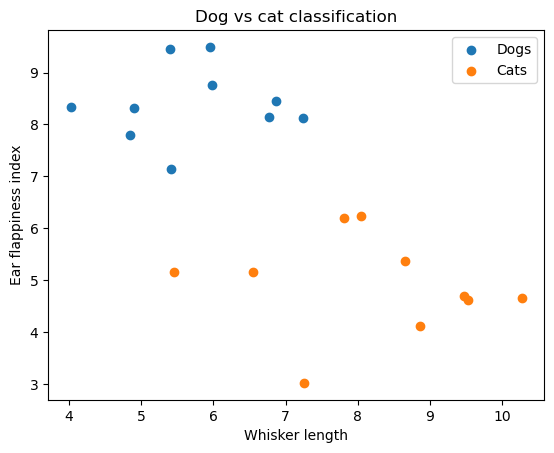

In [6]:
# plot data
plt.scatter(dogs_whisker_length,dogs_ear_flappiness_index,label = "Dogs")
plt.scatter(cat_whisker_length,cat_ear_flappiness_index ,label = "Cats")
plt.xlabel("Whisker length")
plt.ylabel("Ear flappiness index")
plt.title("Dog vs cat classification")
plt.legend() #legend is used to show the label of the data
plt.show()

In [7]:
def compute_error(data_dogs,data_cats,theta,theta0):
    error = 0
    for x_dog in data_dogs:
        if np.dot(theta,x_dog) + theta0 <= 0:
            error += 1
    for x_cats in data_cats:
        if np.dot(theta,x_cats) + theta0 > 0:
            error += 1

    return error


In [8]:
def random_linear_classifier(data_dogs,data_cats,k,d):
    # d is the number of features
    best_error = float('inf')# used to assign positive infinity
    best_theta = None
    best_theta0 = None

    for _ in range(k):
        theta = np.random.normal(size= d)
        theta0 = np.random.normal()

        error = compute_error(data_dogs,data_cats,theta,theta0)

        if error < best_error:
            best_error = error
            best_theta = theta
            best_theta0 = theta0

    return best_theta,best_theta0


In [9]:
# .T is for transpose for converting (2,n) -> (n,2)

dogs_data = np.vstack((dogs_whisker_length,dogs_ear_flappiness_index)).T
cats_data = np.vstack((cat_whisker_length,cat_ear_flappiness_index)).T

In [10]:
dogs_data

array([[6.76405235, 8.14404357],
       [5.40015721, 9.45427351],
       [5.97873798, 8.76103773],
       [7.2408932 , 8.12167502],
       [6.86755799, 8.44386323],
       [4.02272212, 8.33367433],
       [5.95008842, 9.49407907],
       [4.84864279, 7.79484174],
       [4.89678115, 8.3130677 ],
       [5.4105985 , 7.14590426]])

In [11]:
cats_data

array([[ 5.44701018,  5.15494743],
       [ 8.6536186 ,  5.37816252],
       [ 8.8644362 ,  4.11221425],
       [ 7.25783498,  3.01920353],
       [10.26975462,  4.65208785],
       [ 6.54563433,  5.15634897],
       [ 8.04575852,  6.23029068],
       [ 7.81281615,  6.20237985],
       [ 9.53277921,  4.61267318],
       [ 9.46935877,  4.69769725]])

In [12]:
# Run the randon linear classifier
# k = 100, d = 2
best_theta,best_theata0 = random_linear_classifier(dogs_data,cats_data,1000,2)

In [13]:
best_theata0

-0.40317694697317963

In [14]:
best_theta

array([-1.07075262,  1.05445173])

In [15]:
x_vals = np.linspace(2,10,100)
y_vals = (-best_theta[0]/best_theta[1])*x_vals -  (best_theata0/best_theta[1])

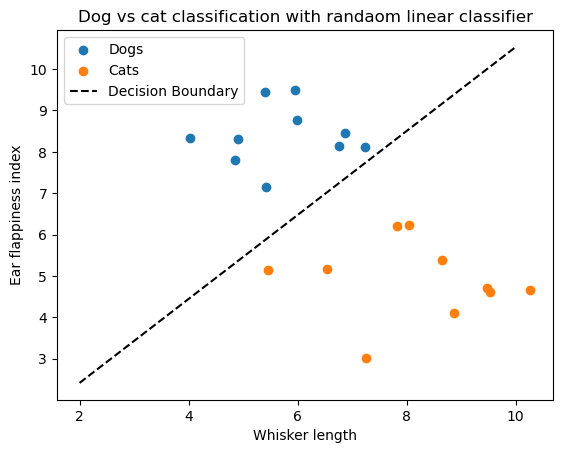

In [16]:
# plot data
plt.scatter(dogs_whisker_length,dogs_ear_flappiness_index,label = "Dogs")
plt.scatter(cat_whisker_length,cat_ear_flappiness_index ,label = "Cats")
plt.plot(x_vals,y_vals,color = 'black',linestyle='--',label ='Decision Boundary')
plt.xlabel("Whisker length")
plt.ylabel("Ear flappiness index")
plt.title("Dog vs cat classification with randaom linear classifier")
plt.legend() #legend is used to show the label of the data
plt.show()